# 04 — Séries temporais e projeção das metas até 2030

Pergunta de negócio: *como prever municípios que podem não atingir metas
futuras?*

## A limitação que define o método

O Indicador Criança Alfabetizada só existe desde 2023. A série disponível é:

| Nível | Pontos observados |
|---|---|
| Brasil | 3 (2023, 2024, 2025) |
| UF | 2 (2023, 2024) |
| Município | 2 (2023, 2024) |

Com dois ou três pontos não há sazonalidade a estimar nem autocorrelação a
modelar — ARIMA e Prophet seriam teatro estatístico. Declarar isso é parte da
entrega. O que faz sentido é um modelo de tendência explícito, com os freios que
a natureza do indicador exige.

In [1]:
import sys, warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))   # torna o pacote `src` importável
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)

## 1. A série nacional

In [2]:
from src.modeling.forecasting import METAS_NACIONAIS, serie_nacional

serie = serie_nacional()
serie

,ano,taxa_observada,meta
0,2023,55.9,NaN
1,2024,59.2,59.9
2,2025,66.0,64.0


In [3]:
variacao = serie["taxa_observada"].diff()
pd.DataFrame({
    "ano": serie["ano"],
    "taxa_observada": serie["taxa_observada"],
    "meta": serie["meta"],
    "variacao_anual": variacao.round(2),
    "acima_da_meta": (serie["taxa_observada"] >= serie["meta"]),
})

,ano,taxa_observada,meta,variacao_anual,acima_da_meta
0,2023,55.9,NaN,NaN,False
1,2024,59.2,59.9,3.3,False
2,2025,66.0,64.0,6.8,True


O Brasil saiu de 55,9% em 2023 para 66,0% em 2025 — mais de 5 pontos percentuais
por ano, acima da trajetória pactuada. É uma boa notícia que precisa ser lida com
cuidado: os primeiros pontos de qualquer indicador educacional são os mais fáceis.

## 2. Três cenários de projeção

In [4]:
from src.modeling.forecasting import projetar_nacional

projecao_br = projetar_nacional(serie)
projecao_br

,ano,projecao_amortecida,projecao_holt,projecao_linear,meta,gap_amortecida_vs_meta,gap_linear_vs_meta,crescimento_anual_observado
0,2026,70.29,70.47,70.47,67.0,3.29,3.47,5.05
1,2027,73.94,75.52,75.52,71.0,2.94,4.52,5.05
2,2028,77.04,80.57,80.57,74.0,3.04,6.57,5.05
3,2029,79.68,85.62,85.62,77.0,2.68,8.62,5.05
4,2030,81.92,90.67,90.67,80.0,1.92,10.67,5.05


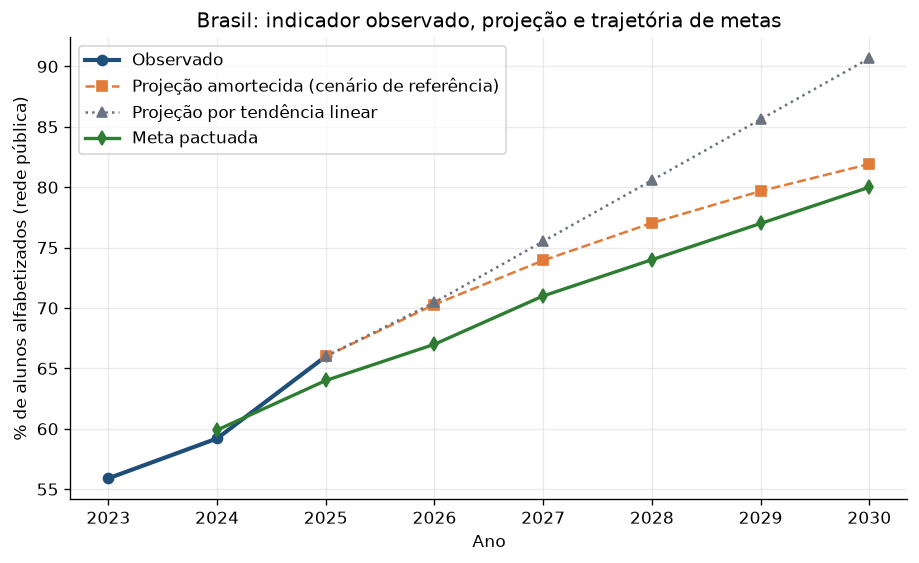

In [5]:
from IPython.display import Image, display
from src.visualization import plots

display(Image(filename=str(plots.projecao_nacional(serie, projecao_br))))

**Leitura dos cenários.**

- *Tendência linear* e *Holt* produzem praticamente a mesma reta. Isso já é um
  resultado a reportar: com três observações, o modelo de série temporal não
  acrescenta informação à tendência simples.
- A extrapolação linear leva o Brasil a **90,7% em 2030**, mais de 10 pontos
  acima da meta. Nenhum sistema educacional do mundo avançou tanto em seis anos.
  O número não é uma previsão, é o que acontece quando se projeta uma reta sem
  considerar que existe um teto em 100%.
- O cenário **amortecido** é o que o relatório adota como referência: o ganho
  anual encolhe a cada ano projetado. Ele leva a 81,9% em 2030 — acima da meta de
  80%, mas por margem estreita.

A conclusão para o gestor: **a meta nacional é alcançável, mas não está
garantida.** Qualquer desaceleração do ritmo atual a coloca em risco.

## 3. Projeção municipal — encolhimento e amortecimento

Dois ajustes são obrigatórios na projeção por município:

**Encolhimento (shrinkage).** A variação individual de 2023 para 2024 tem desvio
de ~17 p.p., muito por conta de municípios pequenos onde poucas turmas mudam o
percentual inteiro. Puxamos metade do peso para o comportamento médio da UF.

**Amortecimento (damping).** O ganho projetado cai a cada ano
(`delta × 0,85^t`). Sem esse freio, um município que subiu 12 p.p. em um ano
chegaria a 2030 acima de 100%.

In [6]:
from src.modeling.forecasting import projetar_municipios

projecao = projetar_municipios()
projecao[["nome_municipio", "sigla_uf", "taxa_2023", "taxa_2024",
          "delta_observado", "delta_projetado", "projecao_2030", "meta_2030",
          "classificacao_ritmo"]].head(10)

,nome_municipio,sigla_uf,taxa_2023,taxa_2024,delta_observado,delta_projetado,projecao_2030,meta_2030,classificacao_ritmo
0,Nova Castilho,SP,40.00,25.00,-15.00,-5.94,4.03,80.0,Em retrocesso
1,Chapada de Areia,TO,50.00,6.25,-43.75,-17.77,0.00,80.0,Em retrocesso
2,Jundiá,RN,54.55,33.33,-21.22,-8.00,5.09,80.0,Em retrocesso
3,Lagoa d'Anta,RN,13.11,11.65,-1.46,1.88,18.29,80.0,Em retrocesso
4,Itaguatins,TO,32.53,18.09,-14.44,-3.12,7.08,80.0,Em retrocesso
5,Barão do Triunfo,RS,88.23,4.40,-83.83,-51.89,0.00,80.0,Em retrocesso
6,Mateiros,TO,27.59,9.09,-18.50,-5.15,0.00,80.0,Em retrocesso
7,São Jorge,RS,76.67,66.70,-9.97,-14.96,13.90,80.0,Em retrocesso
8,Arataca,BA,16.86,13.11,-3.75,-2.33,4.89,80.0,Em retrocesso
9,Três Arroios,RS,100.00,40.00,-60.00,-39.98,0.00,80.0,Em retrocesso


In [7]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 4.2))
eixos[0].hist(projecao["delta_observado"].dropna(), bins=60, color="#6b7280", alpha=0.8)
eixos[0].set_title("Variação observada 2023 → 2024 (bruta)")
eixos[0].set_xlabel("pontos percentuais")
eixos[1].hist(projecao["delta_projetado"].dropna(), bins=60, color="#1f4e79", alpha=0.85)
eixos[1].set_title("Variação usada na projeção (após encolhimento)")
eixos[1].set_xlabel("pontos percentuais")
for e in eixos:
    e.axvline(0, color="#c62828", linestyle="--")
    e.grid(alpha=0.25)
fig.suptitle("O encolhimento reduz a cauda sem apagar o sinal")
plt.show()

projecao[["delta_observado", "delta_projetado"]].describe().round(2)

,delta_observado,delta_projetado
count,5396.00,5396.00
mean,2.67,2.67
std,16.68,10.84
min,-83.83,-51.89
25%,-6.02,-2.13
50%,2.49,2.99
75%,12.02,9.02
max,89.93,47.53


## 4. Quem chega em 2030 e quem não chega

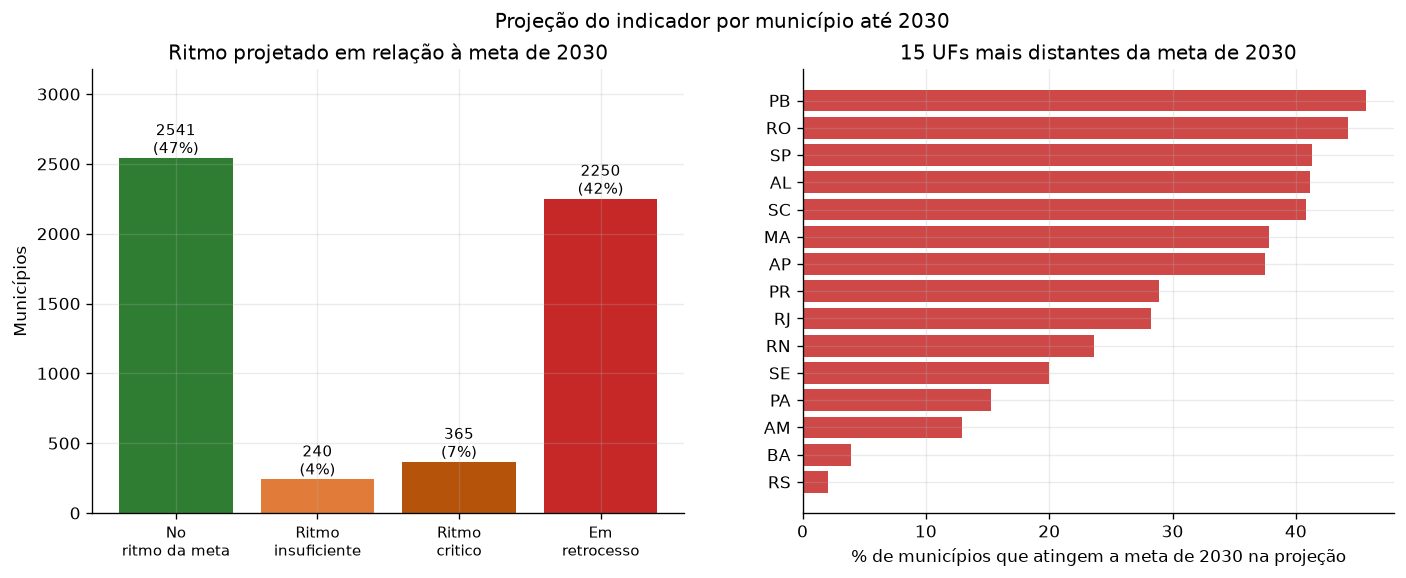

,municípios,percentual
classificacao_ritmo,,
No ritmo da meta,2541,47.1
Em retrocesso,2250,41.7
Ritmo critico,365,6.8
Ritmo insuficiente,240,4.4


In [8]:
display(Image(filename=str(plots.ritmo_municipios(projecao))))

resumo = projecao["classificacao_ritmo"].value_counts().to_frame("municípios")
resumo["percentual"] = (resumo["municípios"] / len(projecao) * 100).round(1)
resumo

**O número que deve abrir a apresentação executiva.** Mesmo com o Brasil
superando a meta nacional no agregado, cerca de **4 em cada 10 municípios
retrocederam** entre 2023 e 2024, e menos da metade chega à meta de 2030 no ritmo
projetado.

A média nacional esconde a dispersão: o país avança porque os municípios grandes
puxam o agregado, enquanto centenas de cidades pequenas andam para trás. Política
pública desenhada sobre a média nacional não alcança justamente quem mais precisa.

In [9]:
from src.modeling.forecasting import resumo_por_uf

resumo_uf = resumo_por_uf(projecao)
resumo_uf.head(12)

,regiao,sigla_uf,municipios,taxa_2024,projecao_2030,meta_2030,perc_atinge_2030,perc_em_retrocesso
22,Sul,RS,443,52.463,8.912,80.0,0.020,0.896
4,Nordeste,BA,407,36.599,33.815,80.0,0.039,0.541
12,Norte,AM,62,44.798,40.503,80.0,0.129,0.581
14,Norte,PA,144,48.721,56.039,80.0,0.153,0.438
11,Nordeste,SE,75,36.447,58.351,80.0,0.200,0.307
10,Nordeste,RN,165,41.831,57.758,80.0,0.236,0.376
19,Sudeste,RJ,92,58.736,69.164,80.0,0.283,0.337
21,Sul,PR,398,74.100,67.293,80.0,0.289,0.626
13,Norte,AP,16,49.449,63.382,80.0,0.375,0.312
6,Nordeste,MA,217,63.297,66.671,80.0,0.378,0.461


## 5. Evolução observada por UF

In [10]:
from src.modeling.forecasting import evolucao_uf

evolucao = evolucao_uf()

fig, eixo = plt.subplots(figsize=(11, 6))
for uf, bloco in evolucao.groupby("sigla_uf"):
    bloco = bloco.sort_values("ano")
    eixo.plot(bloco["ano"], bloco["taxa_media"], marker="o", alpha=0.7, linewidth=1.3)
    eixo.annotate(uf, (bloco["ano"].iloc[-1], bloco["taxa_media"].iloc[-1]),
                  textcoords="offset points", xytext=(5, -3), fontsize=8)
eixo.set_xticks(sorted(evolucao["ano"].unique()))
eixo.set_xlabel("Ano")
eixo.set_ylabel("Taxa média de alfabetização da rede municipal (%)")
eixo.set_title("Evolução por UF entre 2023 e 2024 (camada Gold — evolucao_temporal)")
eixo.grid(alpha=0.25)
plt.show()

## 6. Municípios prioritários para 2030

Cruzando a projeção com o tamanho da rede, sai a lista de onde a intervenção
alcança mais crianças.

In [11]:
from src.data.build_abt import carregar_abt

abt = carregar_abt()
prioridade = projecao.merge(abt[["id_municipio", "populacao_2022"]],
                            on="id_municipio", how="left")
prioridade = prioridade[prioridade["classificacao_ritmo"].isin(
    ["Ritmo critico", "Em retrocesso"])]
prioridade = prioridade.sort_values("populacao_2022", ascending=False)

prioridade.head(20)[["nome_municipio", "sigla_uf", "populacao_2022", "taxa_2023",
                     "taxa_2024", "projecao_2030", "meta_2030", "classificacao_ritmo"]]

,nome_municipio,sigla_uf,populacao_2022,taxa_2023,taxa_2024,projecao_2030,meta_2030,classificacao_ritmo
1036,Salvador,BA,2417678.0,39.16,36.75,30.89,80.0,Em retrocesso
975,Manaus,AM,2063689.0,52.20,50.13,43.92,80.0,Em retrocesso
2086,Curitiba,PR,1773718.0,70.41,65.96,55.05,80.0,Em retrocesso
1834,Recife,PE,1488920.0,62.39,54.36,49.45,80.0,Em retrocesso
570,Porto Alegre,RS,1332845.0,40.04,20.40,0.00,NaN,Em retrocesso
788,Belém,PA,1303403.0,48.22,46.08,46.61,80.0,Em retrocesso
2312,Campinas,SP,1139047.0,41.69,41.49,46.64,80.0,Em retrocesso
620,São Gonçalo,RJ,896744.0,45.67,43.71,45.65,80.0,Em retrocesso
3395,São Bernardo do Campo,SP,810729.0,55.57,54.16,57.16,80.0,Em retrocesso
503,Duque de Caxias,RJ,808161.0,47.15,45.37,47.63,80.0,Em retrocesso


## 7. Limitações declaradas

1. **Duas observações por município.** A projeção é uma classificação de ritmo,
   não uma previsão pontual confiável para uma cidade específica.
2. **Sem intervalo de confiança formal.** Um intervalo estimado sobre dois pontos
   daria falsa sensação de rigor; os três cenários nacionais cumprem esse papel.
3. **A variação 2023→2024 pode conter mudança metodológica do INEP**, não apenas
   aprendizado real. Com uma terceira medição municipal em 2025, o método fica
   muito mais sólido.
4. **O amortecimento de 0,85 é uma escolha**, ancorada na saturação esperada mas
   não estimada dos dados — só uma série mais longa permitiria estimá-la.

Próximo notebook: **05 — aprendizado por reforço**.